# 04 — Model Training

This notebook performs a patient‑level train/validation/test split, builds the preprocessing pipeline, trains a baseline logistic regression model, and saves all resulting artefacts.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import joblib

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

from pathlib import Path
from src.config import num_cols, cat_cols, target_col, drop_cols
from src.modeling import (
    patient_split, build_preprocessor, 
    train_all_models, compute_metrics
)
from src.visualization import plot_roc_curve, plot_pr_curve

In [2]:
# Load dataset
df = pd.read_csv("../data/processed/final_migraine.csv")
df.shape

(4152, 26)

In [3]:
# Split
train_df, valid_df, test_df = patient_split(df)

X_tr = train_df[num_cols + cat_cols]
y_tr = train_df[target_col].values

X_val = valid_df[num_cols + cat_cols]
y_val = valid_df[target_col].values

X_te = test_df[num_cols + cat_cols]
y_te = test_df[target_col].values

In [4]:
# Preprocessing
pre = build_preprocessor(num_cols, cat_cols)
X_tr_prep = pre.fit_transform(X_tr)
X_val_prep = pre.transform(X_val)
X_te_prep = pre.transform(X_te)

joblib.dump(pre, "../models/preprocessor.pkl")
feature_names = pre.get_feature_names_out(num_cols + cat_cols)

In [5]:
# Train models
models = train_all_models(X_tr_prep, y_tr)

pd.DataFrame(X_tr_prep).to_csv("../data/processed/X_tr_prep.csv", index=False)
pd.DataFrame(y_tr, columns=["target"]).to_csv("../data/processed/y_tr.csv", index=False)
train_df[["id"]].to_csv("../data/processed/train_ids.csv", index=False)

In [6]:
# Validation metrics
results = {
    name: compute_metrics(model, X_val_prep, y_val)
    for name, model in models.items()
}

pd.DataFrame(results).to_csv("../reports/tables/validation_metrics.csv", index=False)
valid_df[["id"]].to_csv("../data/processed/valid_ids.csv", index=False)

In [7]:
# Test metrics
test_results = {
    name: compute_metrics(model, X_te_prep, y_te)
    for name, model in models.items()
}

df_test = pd.DataFrame(test_results).T
df_test.to_csv("../reports/tables/test_metrics.csv", index=True)
test_df[["id"]].to_csv("../data/processed/test_ids.csv", index=False)
pd.DataFrame(X_te_prep, columns=feature_names).to_csv("../data/processed/X_te_prep.csv", index=False)
pd.DataFrame(y_te, columns=["target"]).to_csv("../data/processed/y_te.csv", index=False)

for name, model in models.items():
    filename = f"../models/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)

df_test

,ROC-AUC,PR-AUC,Brier,ECE,TP,TN,FP,FN,Precision,Sensitivity
logistic_regression,0.707714,0.748533,0.215358,0.073488,433.0,158.0,197.0,91.0,0.687302,0.826336
gradient_boosting,0.664751,0.718180,0.233590,0.099338,409.0,155.0,200.0,115.0,0.671593,0.780534
xgboost,0.654075,0.705607,0.242724,0.130866,412.0,147.0,208.0,112.0,0.664516,0.786260


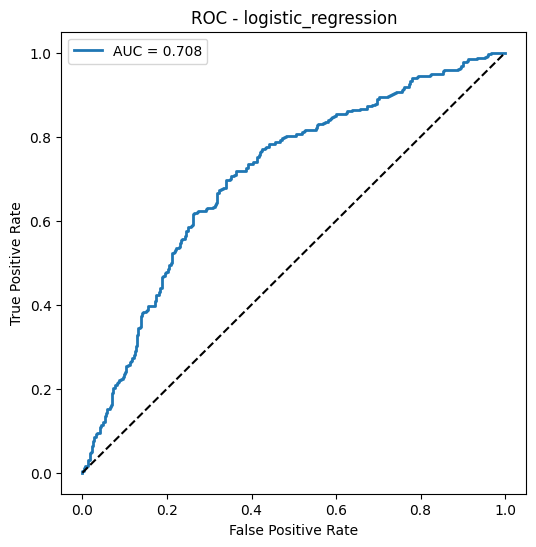

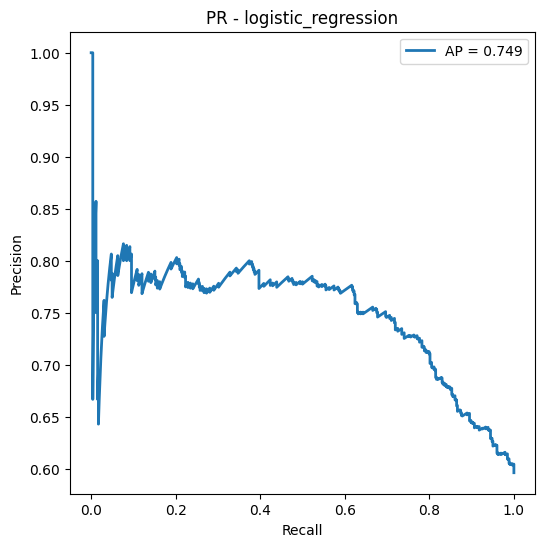

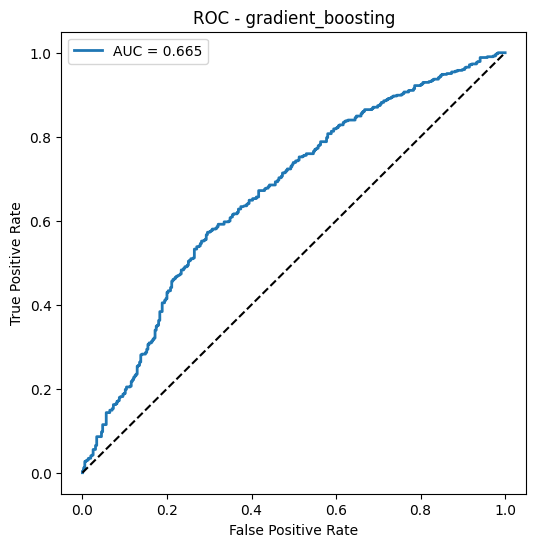

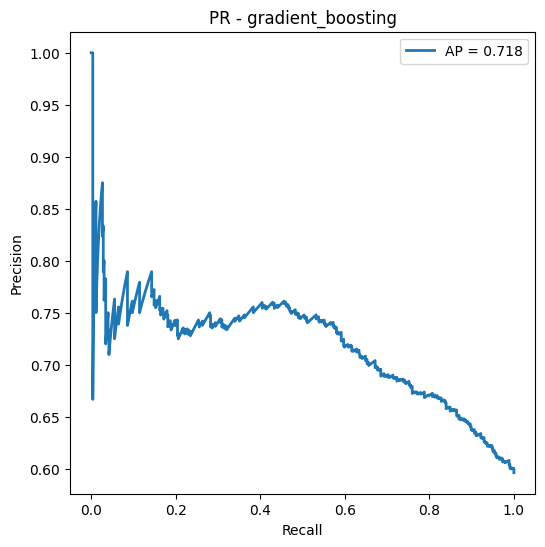

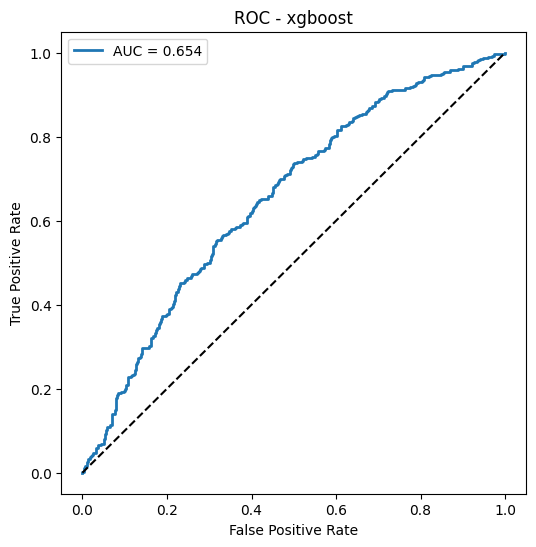

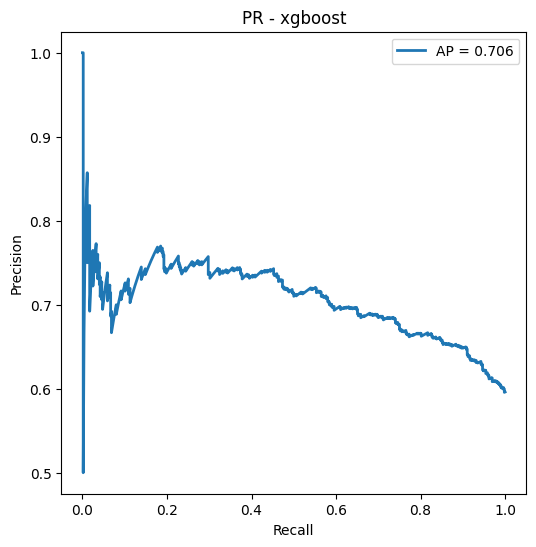

In [8]:
# Visualizations
for name, model in models.items():
    fig_roc = plot_roc_curve(model, X_te_prep, y_te, f"ROC - {name}")
    fig_roc.savefig(f"../reports/figures/roc_test_{name}.png", dpi=300)

    fig_pr = plot_pr_curve(model, X_te_prep, y_te, f"PR - {name}")
    fig_roc.savefig(f"../reports/figures/pr_test_{name}.png", dpi=300)